In [36]:
#Check everything works
from ollama import chat
from ollama import ChatResponse

response: ChatResponse = chat(model='qwen3:30b', messages=[
  {
    'role': 'user',
    'content': 'Why is the sky blue?',
  },
])
print(response['message']['content'])
# or access fields directly from the response object
print(response.message.content)

The sky appears blue due to a phenomenon called **Rayleigh scattering**.

Here’s how it works:

1. **Sunlight is made of all colors**: Sunlight looks white, but it’s actually a mix of all the colors of the rainbow (red, orange, yellow, green, blue, indigo, violet).

2. **Earth’s atmosphere has tiny particles and molecules**: As sunlight enters the atmosphere, it collides with molecules (like nitrogen and oxygen) and small particles.

3. **Shorter wavelengths scatter more**: Blue and violet light have shorter wavelengths than red, orange, or yellow light. Because of this, they scatter much more easily in all directions when they hit air molecules.

4. **Our eyes are more sensitive to blue**: Although violet light scatters even more than blue, our eyes are more sensitive to blue light and less sensitive to violet. Also, some of the violet light is absorbed by the upper atmosphere.

So, even though violet light scatters the most, we see the sky as **blue** because:
- Blue light is scatter

In [37]:
#Model prompting function
def chat_with_model_cust(prompt, sentence):
  response: ChatResponse = chat(model='qwen3:30b', messages=[
  {'role': 'system', 'content': prompt},
  {'role': 'user', 'content': sentence,},
  ])
  print(response['message']['content'])
  return response

In [38]:
#Remove the thinking part in output
import re

def clean_output(raw_output: str) -> str:
    cleaned = re.sub(r"<think>.*?</think>", "", raw_output, flags=re.DOTALL)
    cleaned = cleaned.strip()
    return cleaned

In [39]:
#Load data
import numpy as np
import pandas as pd

ds_CIA = pd.read_csv("transcript_spell_checked.csv")
print(ds_CIA.head())

ds_2 = pd.read_csv("group_2_url_1_transcript.csv")
print(ds_2.head())

ds_17 = pd.read_csv("group_17_url_1_transcript.csv")
print(ds_17.head())

ds_18 = pd.read_csv("group_18_url_1_transcript.csv")
print(ds_18.head())

ds_19 = pd.read_csv("group_19_url_1_transcript.csv")
print(ds_19.head())

  Start Time  End Time                                           Sentence  \
0   00:00:00  00:00:07  Program zawiera treści nieodpowiednie dla widz...   
1   00:00:07  00:00:09               Oglądasz na własną odpowiedzialność.   
2   00:00:10  00:00:13                               Jedziemy do Piękowa!   
3   00:00:14  00:00:17              Krakowiacek jeden, a okoliców siedem.   
4   00:00:19  00:00:22  Tak go dźgnąłem w tą tarczę i widziałem, że si...   

                                         Translation Emotion_fine  \
0  The program contains content inappropriate for...      warning   
1                        You watch at your own risk.      caution   
2                             We're going to Pięków!   excitement   
3           One Krakowiacek, and seven surroundings.        pride   
4  So I stabbed him in that shield and I saw that...   irritation   

  Emotion_core Intensity  sentence_length  emotion_coverage predicted_emotion  \
0         fear      mild               14

In [40]:
#Write prompt
prompt = "Analyze the user sentence and classify it as one of the six core emotions (happiness, sadness, anger, surprise, fear, disgust) or neutral. Print just the emotion. Don't print youur thinking."

In [41]:
#Select usefull data
CIA_column = ds_CIA["Emotion_core"]
CIA_column_n = CIA_column[:25]
prompt_list = ds_CIA["Translation"].tolist()

two_column = ds_2["Emotion_core"]
two_column_n = two_column[:25]
two_list = ds_2["Translation"].tolist()

seven_column = ds_17["Emotion_core"]
seven_column_n = seven_column[:25]
seven_list = ds_17["Translation"].tolist()

eight_column = ds_18["Emotion_core"]
eight_column_n = eight_column[:25]
eight_list = ds_18["Translation"].tolist()

nine_column = ds_19["Emotion_core"]
nine_column_n = nine_column[:25]
nine_list = ds_19["Translation"].tolist()

In [42]:
#Run the model on everything
model_preds = []
two_preds = []
seven_preds = []
eight_preds = []
nine_preds = []

for i in prompt_list[:25]:
    answer = chat_with_model_cust(i, prompt)
    answer_clean = clean_output(answer['message']['content'])
    model_preds.append(answer_clean.lower())

for i in two_list[:25]:
    answer = chat_with_model_cust(i, prompt)
    two_preds.append(answer['message']['content'].lower())

for i in seven_list[:25]:
    answer = chat_with_model_cust(i, prompt)
    seven_preds.append(answer['message']['content'].lower())

for i in eight_list[:25]:
    answer = chat_with_model_cust(i, prompt)
    eight_preds.append(answer['message']['content'].lower())

for i in nine_list[:25]:
    answer = chat_with_model_cust(i, prompt)
    nine_preds.append(answer['message']['content'].lower())

Anger
Surprise
Happiness
Surprise
Anger
Surprise
Surprise
Neutral
Sadness
Fear
Happiness
Surprise
Neutral
Happiness
Neutral
Disgust
Anger
Disgust
Happiness
Sadness
Happiness
Disgust
Anger
Happiness
Happiness
Neutral
Happiness
Surprise
Neutral
Sadness
Surprise
Surprise
Surprise
Neutral
Neutral
Resilience
Neutral
Neutral
Neutral
Fear
Fear
Neutral
Happiness
Neutral
Happiness
Neutral
Neutral
Happiness
Happiness
Happiness
Surprise
Surprise
Surprise
Anger
Happiness
Surprise
Anger
Neutral
Neutral
Happiness
Neutral
Happiness
Happiness
Happiness
Longing
Surprise
Excitement
Fear
Happiness
Anger
Surprise
Happiness
Neutral
Neutral
Surprise
Surprise
Surprise
Surprise
Surprise
Surprise
Surprise
Surprise
Surprise
Sadness
Disgust
Fear
Sadness
Sadness
Sadness
Happiness
Sadness
Happiness
Sadness
Sadness
Happiness
Sadness
Surprise
Happiness
Sadness
Happiness
Happiness
Surprise
Fear
Happiness
Surprise
Sadness
Surprise
Surprise
Neutral
Surprise
Surprise
Surprise
Surprise
Surprise
Surprise
Surprise
Fear
Neu

In [43]:
#Make sure everything went correctly
df = pd.DataFrame(model_preds)
df_2 = pd.DataFrame(two_preds)
df_17 = pd.DataFrame(seven_preds)
df_18 = pd.DataFrame(eight_preds)
df_19 = pd.DataFrame(nine_preds)
print(model_preds)
print(df.head())
print(df_2.head())
print(df_17.head())
print(df_18.head())
print(df_19.head())

['anger', 'surprise', 'happiness', 'surprise', 'anger', 'surprise', 'surprise', 'neutral', 'sadness', 'fear', 'happiness', 'surprise', 'neutral', 'happiness', 'neutral', 'disgust', 'anger', 'disgust', 'happiness', 'sadness', 'happiness', 'disgust', 'anger', 'happiness', 'happiness']
           0
0      anger
1   surprise
2  happiness
3   surprise
4      anger
           0
0    neutral
1  happiness
2   surprise
3    neutral
4    sadness
           0
0   surprise
1   surprise
2   surprise
3      anger
4  happiness
          0
0  surprise
1  surprise
2  surprise
3  surprise
4  surprise
           0
0  happiness
1   surprise
2       fear
3  happiness
4   surprise


In [44]:
#Classification report
from sklearn.metrics import classification_report
print(classification_report(CIA_column_n, model_preds, zero_division=0, digits=3))
print(classification_report(two_column_n, two_preds, zero_division=0, digits=3))
print(classification_report(seven_column_n, seven_preds, zero_division=0, digits=3))
print(classification_report(eight_column_n, eight_preds, zero_division=0, digits=3))
print(classification_report(nine_column_n, nine_preds, zero_division=0, digits=3))

              precision    recall  f1-score   support

       anger      0.500     0.400     0.444         5
     disgust      0.000     0.000     0.000         0
        fear      0.000     0.000     0.000         3
   happiness      0.571     0.500     0.533         8
     neutral      0.333     0.250     0.286         4
     sadness      1.000     0.667     0.800         3
    surprise      0.000     0.000     0.000         2

    accuracy                          0.360        25
   macro avg      0.344     0.260     0.295        25
weighted avg      0.456     0.360     0.401        25

              precision    recall  f1-score   support

        fear      0.500     1.000     0.667         1
   happiness      1.000     0.429     0.600        14
     neutral      0.636     0.778     0.700         9
  resilience      0.000     0.000     0.000         0
     sadness      0.000     0.000     0.000         0
    surprise      0.250     1.000     0.400         1

    accuracy           

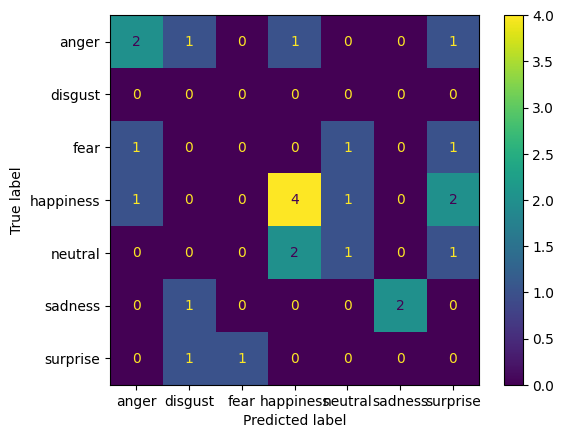

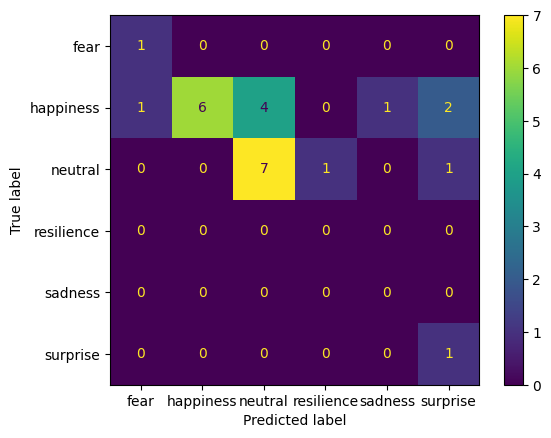

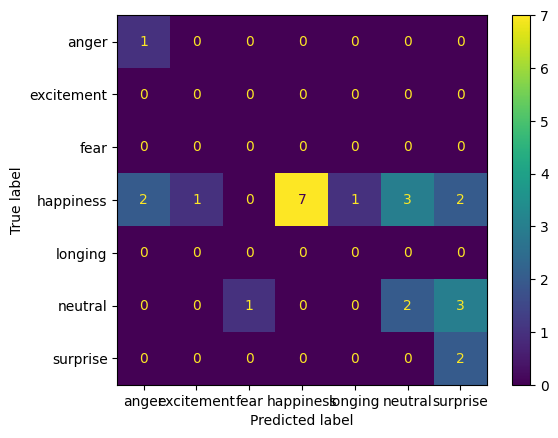

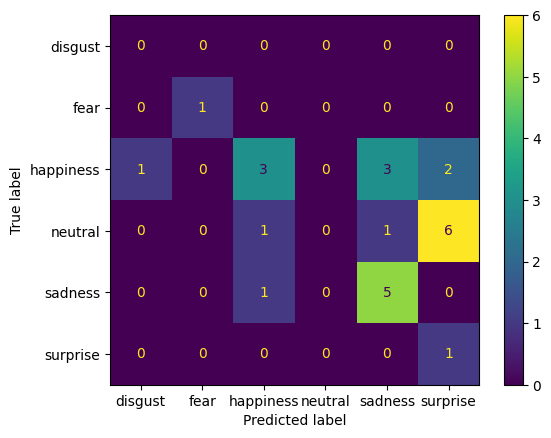

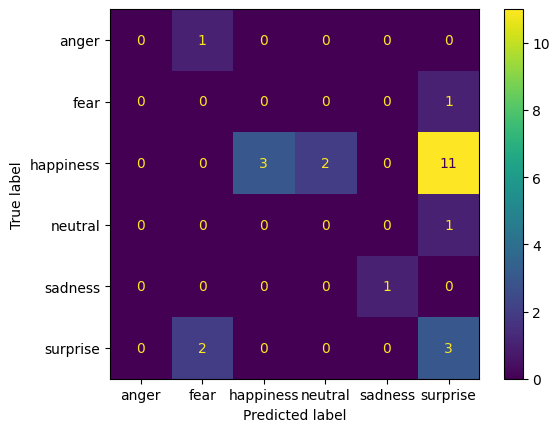

In [45]:
#Confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(CIA_column_n, model_preds)
plt.show()

ConfusionMatrixDisplay.from_predictions(two_column_n, two_preds)
plt.show()

ConfusionMatrixDisplay.from_predictions(seven_column_n, seven_preds)
plt.show()

ConfusionMatrixDisplay.from_predictions(eight_column_n, eight_preds)
plt.show()

ConfusionMatrixDisplay.from_predictions(nine_column_n, nine_preds)
plt.show()

In [46]:
#Print all sentences to see what errors it made
CIA_column_n, model_preds, df

error_set = pd.DataFrame({
    'Sentence': ds_CIA['Translation'][:25],
    'True_label': CIA_column_n,
    'Prediction': model_preds
})

error_set_2 = pd.DataFrame({
    'Sentence': ds_2['Translation'][:25],
    'True_label': two_column_n,
    'Prediction': two_preds
})

error_set_17 = pd.DataFrame({
    'Sentence': ds_17['Translation'][:25],
    'True_label': seven_column_n,
    'Prediction': seven_preds
})

error_set_18 = pd.DataFrame({
    'Sentence': ds_18['Translation'][:25],
    'True_label': eight_column_n,
    'Prediction': eight_preds
})

error_set_19 = pd.DataFrame({
    'Sentence': ds_19['Translation'][:25],
    'True_label': nine_column_n,
    'Prediction': nine_preds
})

In [47]:
print(error_set)
print(error_set_2)
print(error_set_17)
print(error_set_18)
print(error_set_19)

                                             Sentence True_label Prediction
0   The program contains content inappropriate for...       fear      anger
1                         You watch at your own risk.       fear   surprise
2                              We're going to Pięków!  happiness  happiness
3            One Krakowiacek, and seven surroundings.  happiness   surprise
4   So I stabbed him in that shield and I saw that...      anger      anger
5                                   So what the hell?      anger   surprise
6                          We're going full throttle!  happiness   surprise
7             At six at night I went to the hospital.       fear    neutral
8                               I felt fucking awful.    sadness    sadness
9   And at night did you feel like your whole life...   surprise       fear
10                                                No.    neutral  happiness
11                   Have you been working that long?    neutral   surprise
12          